NAME: OJO PRECIOUS MOJOLAOLUWA



Week 1 Data Analyst Intern



AnalystLab Africa

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PART 2- DATA SET INSPECTION

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("--- Shape ---")
print(df.shape)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Duplicates ---")
print(df.duplicated().sum())


--- Shape ---
(7043, 21)

--- Missing Values ---
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

--- Duplicates ---
0


PART 3- BUSINESS DATA ANALYSIS

In [4]:
# Cleaning data for analysis
df_clean = df.dropna(subset=['TotalCharges'])
df_clean['Churn_Flag'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_351/3359960160.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Churn_Flag'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})


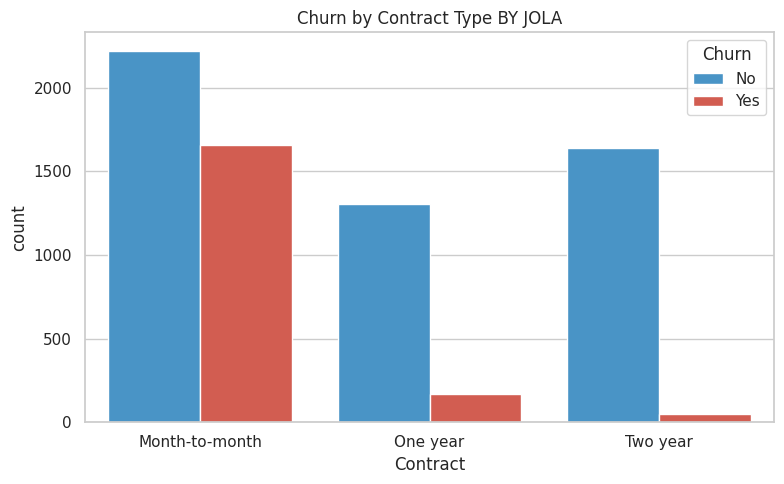

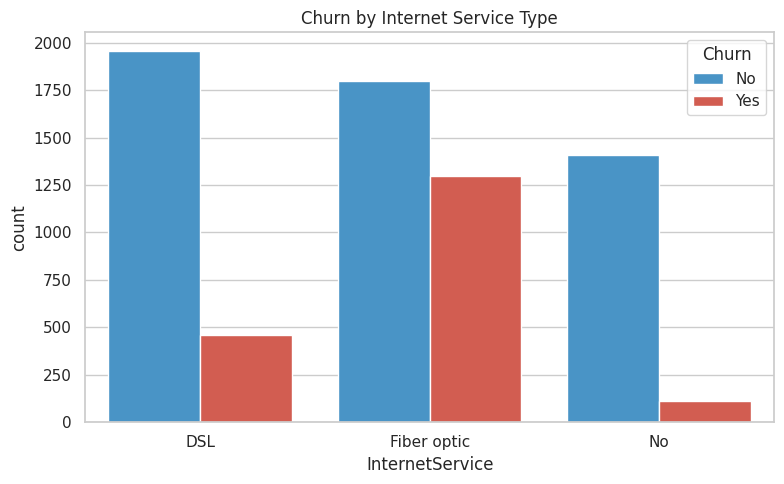

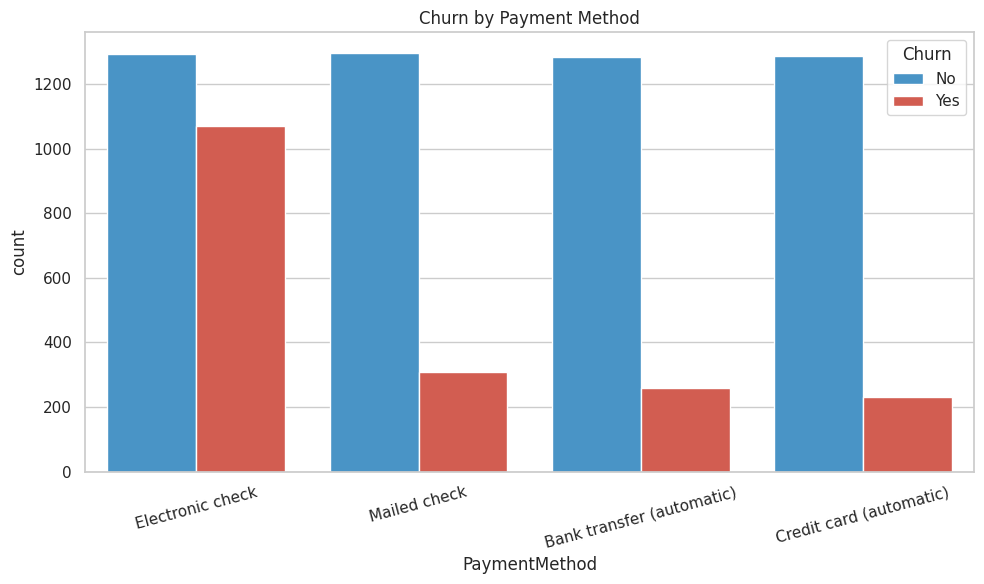

In [5]:
import os

# --- THREE BAR CHARTS ---
os.makedirs('my_plots', exist_ok=True)

# Churn by Contract Type
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='Contract', hue='Churn', palette=['#3498db', '#e74c3c'])
plt.title('Churn by Contract Type BY JOLA')
plt.tight_layout()
plt.savefig('my_plots/1_churn_by_contract_type.png')
plt.show()

# Churn by Internet Service
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='InternetService', hue='Churn', palette=['#3498db', '#e74c3c'])
plt.title('Churn by Internet Service Type')
plt.tight_layout()
plt.savefig('my_plots/2_churn_by_internet_service.png')
plt.show()

# Churn by Payment Method
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='PaymentMethod', hue='Churn', palette=['#3498db', '#e74c3c'])
plt.xticks(rotation=15)
plt.title('Churn by Payment Method')
plt.tight_layout()
plt.savefig('my_plots/3_churn_by_payment_method.png')
plt.show()

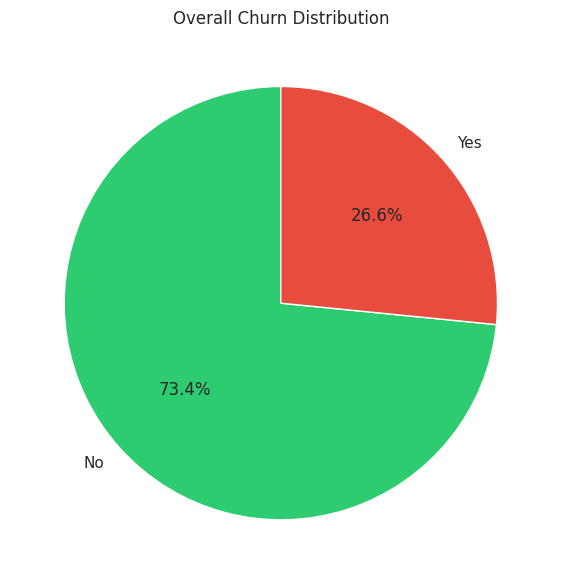

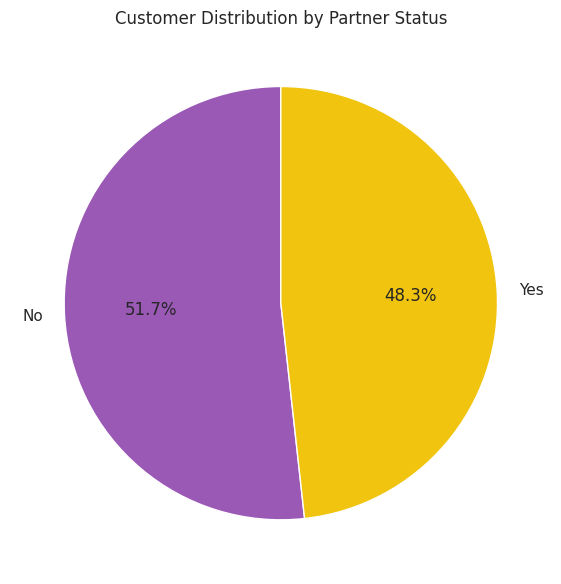

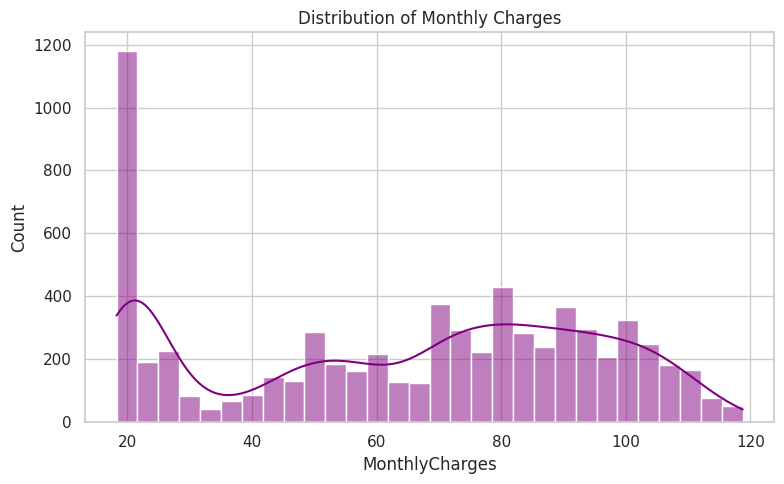

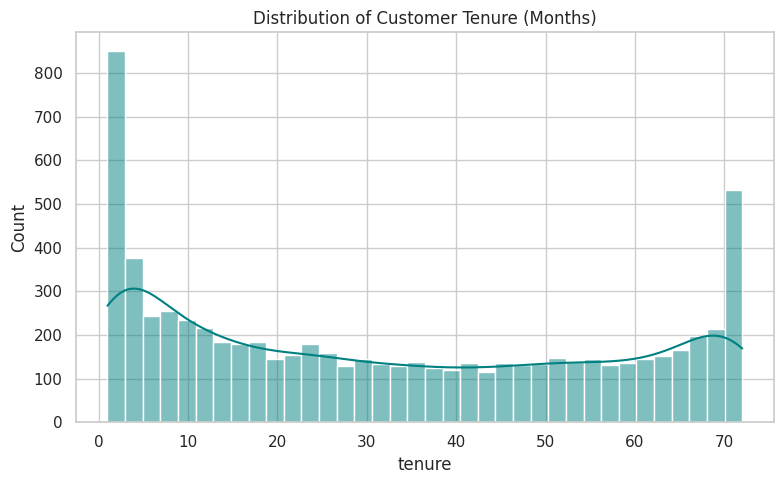

/tmp/ipykernel_351/2507788876.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])


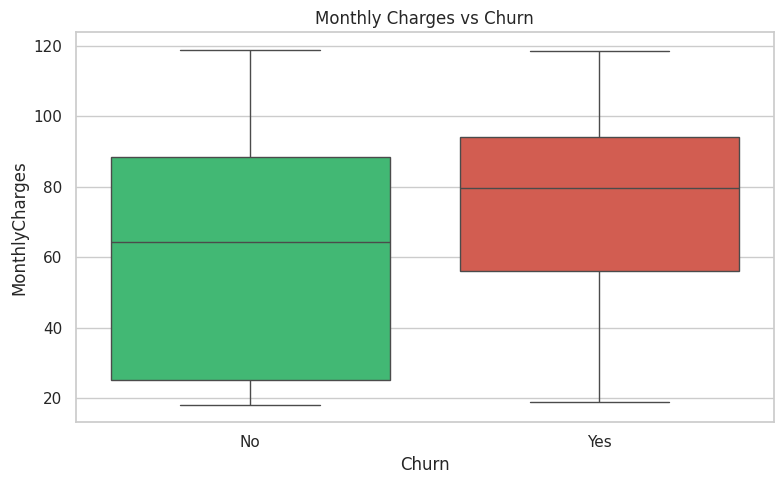

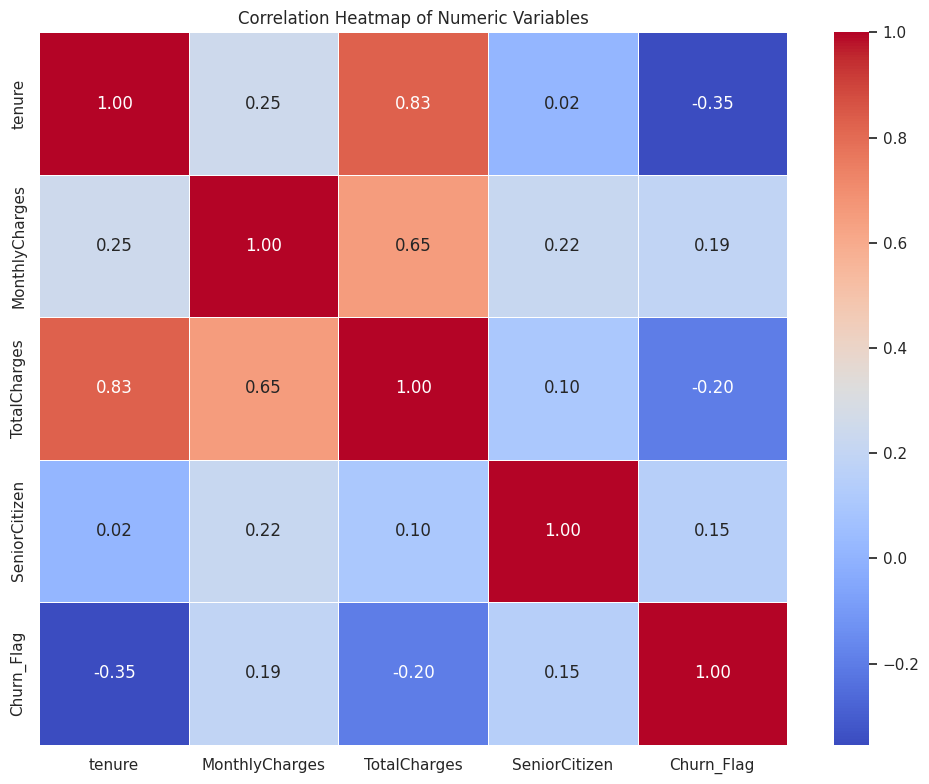

In [6]:
# --- TWO PIE CHARTS ---

# Overall Churn Distribution
plt.figure(figsize=(6,6))
df_clean['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Overall Churn Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('my_plots/4_overall_churn_distribution.png')
plt.show()

# Customer Distribution by Partner Status
plt.figure(figsize=(6,6))
df_clean['Partner'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#9b59b6', '#f1c40f'], startangle=90)
plt.title('Customer Distribution by Partner Status')
plt.ylabel('')
plt.tight_layout()
plt.savefig('my_plots/5_customer_by_partner_status.png')
plt.show()

# --- TWO HISTOGRAMS ---
# Distribution of Monthly Charges
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='MonthlyCharges', bins=30, kde=True, color='purple')
plt.title('Distribution of Monthly Charges')
plt.tight_layout()
plt.savefig('my_plots/6_monthly_charges_distribution.png')
plt.show()

# Distribution of Customer Tenure
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='tenure', bins=36, kde=True, color='teal')
plt.title('Distribution of Customer Tenure (Months)')
plt.tight_layout()
plt.savefig('my_plots/7_customer_tenure_distribution.png')
plt.show()

# --- ONE BOX PLOT ---
# Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.savefig('my_plots/8_monthly_charges_vs_churn.png')
plt.show()

# --- ONE CORRELATION HEATMAP ---
plt.figure(figsize=(10,8))
corr_matrix = df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Flag']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.savefig('my_plots/9_correlation_heatmap.png')
plt.show()

In [9]:
import shutil
from google.colab import files

shutil.make_archive('all_plots', 'zip', 'my_plots')

# Download the zip file
files.download('all_plots.zip')

print("All plots have been zipped into 'all_plots.zip'.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All plots have been zipped into 'all_plots.zip'.
